In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0,str(PROJECT_ROOT))
print(os.getcwd())
sys.executable

c:\Dev\Projects\customer-churn-intelligence-platform\notebooks


'c:\\Dev\\Projects\\customer-churn-intelligence-platform\\.venv\\Scripts\\python.exe'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config.settings import CLEAN_DATA_FILE

## 1. Dataset & Data Quality

This section examines the structure, completeness, temporal coverage, and
basic statistical properties of the cleaned transaction dataset before
performing customer-level exploratory analysis.

In [3]:
df = pd.read_csv(CLEAN_DATA_FILE,parse_dates=["invoice_date"])
df.head()

,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancellation,is_adjustment,is_operational_negative,is_zero_quantity,is_zero_price_activity,is_zero_price_anonymous,is_purchase,transaction_value
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,False,False,False,False,False,True,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,False,False,False,False,True,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,False,False,False,False,True,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,False,False,False,False,False,True,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,False,False,False,False,False,True,30.0


In [4]:
df.shape

(779495, 16)

In [4]:
print(f"Number of rows : {len(df)}")
print(f"Number of columns : {df.shape[1]}")
print(f"Number of Customers : {df['customer_id'].nunique()}")
print(f"Number of Orders : {df['invoice'].nunique()}")
print(f"Number of Products : {df['stock_code'].nunique()}")
print(f"Number of Countries : {df['country'].nunique()}")

Number of rows : 779495
Number of columns : 16
Number of Customers : 5881
Number of Orders : 36975
Number of Products : 4631
Number of Countries : 41


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779495 entries, 0 to 779494
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   invoice                  779495 non-null  int64         
 1   stock_code               779495 non-null  object        
 2   description              779495 non-null  object        
 3   quantity                 779495 non-null  int64         
 4   invoice_date             779495 non-null  datetime64[ns]
 5   unit_price               779495 non-null  float64       
 6   customer_id              779495 non-null  float64       
 7   country                  779495 non-null  object        
 8   is_cancellation          779495 non-null  bool          
 9   is_adjustment            779495 non-null  bool          
 10  is_operational_negative  779495 non-null  bool          
 11  is_zero_quantity         779495 non-null  bool          
 12  is_zero_price_ac

In [7]:
df.describe()

,invoice,quantity,invoice_date,unit_price,customer_id,transaction_value
count,779495.000000,779495.000000,779495,779495.000000,779495.000000,779495.000000
mean,537427.005391,13.507085,2011-01-03 01:46:36.061116416,3.218199,15320.262918,22.289821
min,489434.000000,1.000000,2009-12-01 07:45:00,0.000000,12346.000000,0.000000
25%,514483.000000,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,536754.000000,6.000000,2010-12-02 14:09:00,1.950000,15246.000000,12.480000
75%,562002.000000,12.000000,2011-08-01 13:48:00,3.750000,16794.000000,19.800000
max,581587.000000,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,26901.961110,146.540284,NaN,29.674823,1695.722988,227.416962


In [8]:
missing = pd.DataFrame({
    "count":df.isna().sum(),
    "percentage":df.isna().mean()*100
})
missing=missing.sort_values("percentage",ascending=False)
missing

,count,percentage
invoice,0,0.0
stock_code,0,0.0
description,0,0.0
quantity,0,0.0
invoice_date,0,0.0
unit_price,0,0.0
customer_id,0,0.0
country,0,0.0
is_cancellation,0,0.0
is_adjustment,0,0.0


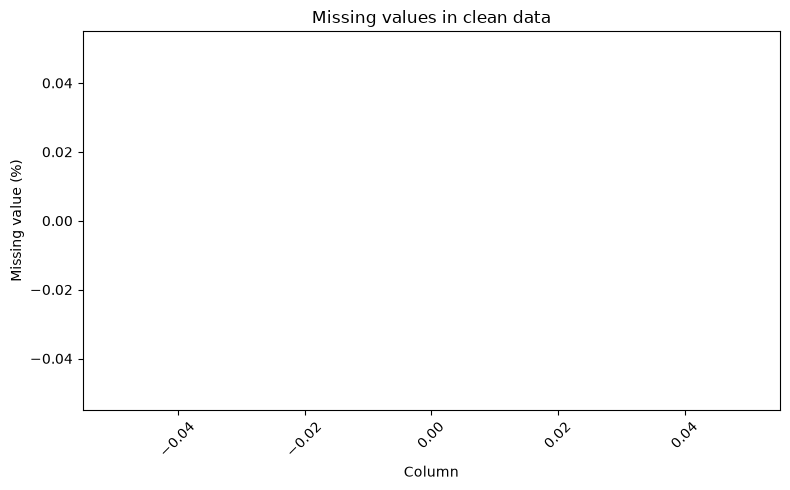

In [9]:
missing_plot = missing[missing["count"] > 0]
plt.figure(figsize=(8,5))
plt.bar(missing_plot.index,missing_plot["percentage"])

plt.xlabel("Column")
plt.ylabel("Missing value (%)")
plt.title("Missing values in clean data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(f"Start : {df['invoice_date'].min()}")
print(f"End : {df['invoice_date'].max()}")

Start : 2009-12-01 07:45:00
End : 2011-12-09 12:50:00


In [13]:
data_span=(df["invoice_date"].max()-df["invoice_date"].min())
print(f"Dataset duration : {data_span.days} days")

Dataset duration : 738 days


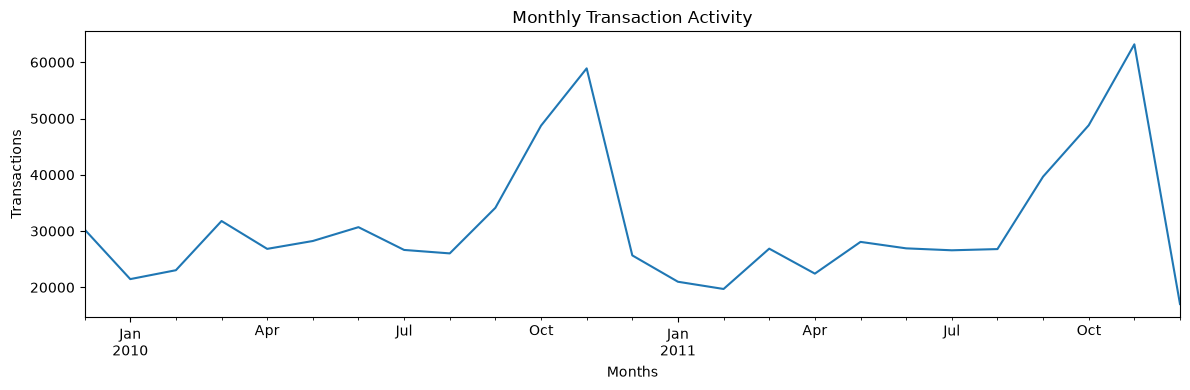

In [19]:
monthly_transactions = (df.set_index("invoice_date").resample("ME").size())

plt.figure(figsize=(12,4))

monthly_transactions.plot()
plt.xlabel("Months")
plt.ylabel("Transactions")
plt.title("Monthly Transaction Activity")
plt.tight_layout()
plt.show()

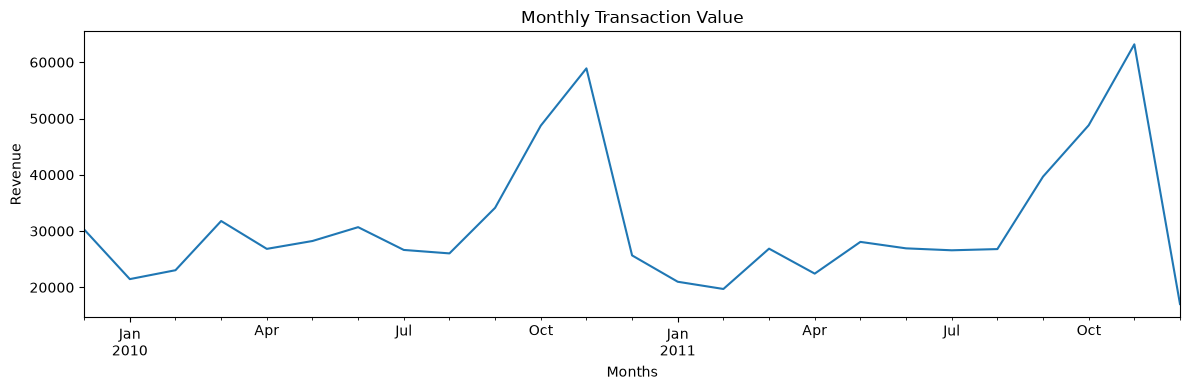

In [22]:
monthly_revenue = (df.set_index("invoice_date")["transaction_value"].resample("ME").size())

plt.figure(figsize=(12,4))

monthly_revenue.plot()

plt.xlabel("Months")
plt.ylabel("Revenue")
plt.title("Monthly Transaction Value")
plt.tight_layout()
plt.show()

In [23]:
df[["quantity","unit_price","transaction_value"]].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.90,0.95,0.99])

,quantity,unit_price,transaction_value
count,779495.000000,779495.000000,779495.000000
mean,13.507085,3.218199,22.289821
std,146.540284,29.674823,227.416962
min,1.000000,0.000000,0.000000
1%,1.000000,0.290000,0.580000
5%,1.000000,0.420000,1.250000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.480000
75%,12.000000,3.750000,19.800000
90%,24.000000,6.750000,35.700000


In [24]:
df[["quantity","unit_price","transaction_value"]].skew()

quantity             396.288664
unit_price           240.556878
transaction_value    579.600280
dtype: float64

In [25]:
quantity_99 = df["quantity"].quantile(0.99)
print(f"99th percentile of quantity : {quantity_99}")

99th percentile of quantity : 144.0


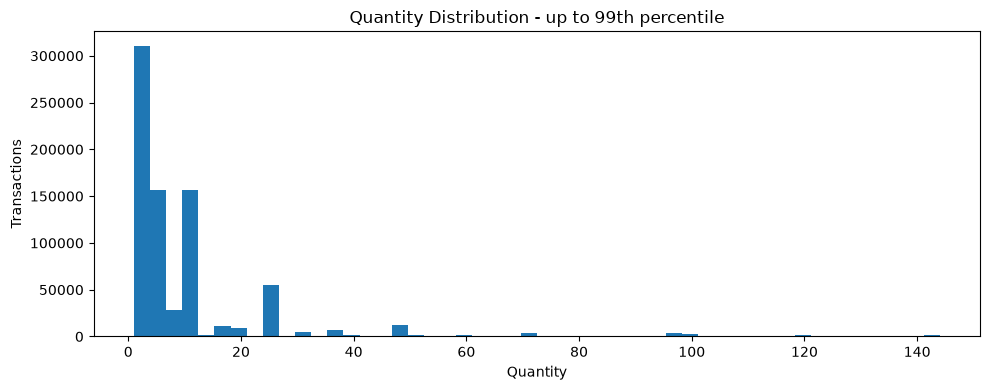

In [30]:
plt.figure(figsize=(10,4))

plt.hist(
    df.loc[df["quantity"]<=quantity_99,"quantity"],
    bins=50
)
plt.xlabel("Quantity")
plt.ylabel("Transactions")
plt.title("Quantity Distribution - up to 99th percentile")
plt.tight_layout()
plt.show()

In [31]:
price_99 = df["unit_price"].quantile(0.99)
print(f"99th percentile of unit_price : {price_99}")

99th percentile of unit_price : 14.95


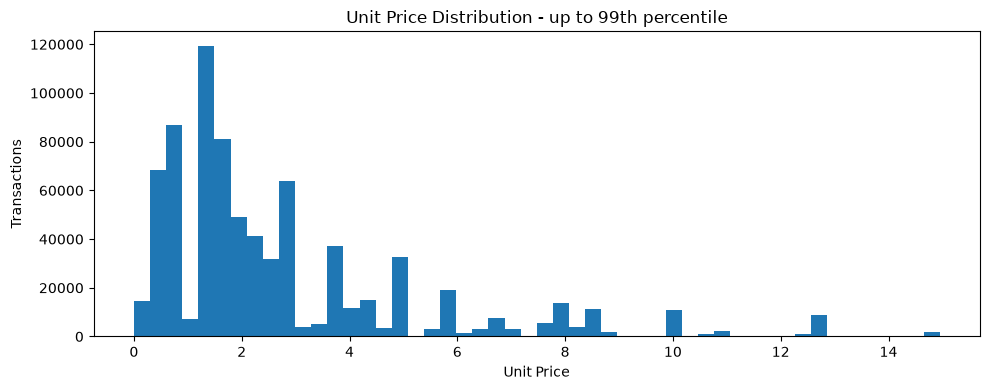

In [32]:
plt.figure(figsize=(10,4))

plt.hist(
    df.loc[df["unit_price"]<=price_99,"unit_price"],
    bins=50
)
plt.xlabel("Unit Price")
plt.ylabel("Transactions")
plt.title("Unit Price Distribution - up to 99th percentile")
plt.tight_layout()
plt.show()

In [33]:
value_99 = df["transaction_value"].quantile(0.99)
print(f"99th percentile of trasaction_value : {value_99}")

99th percentile of trasaction_value : 203.52


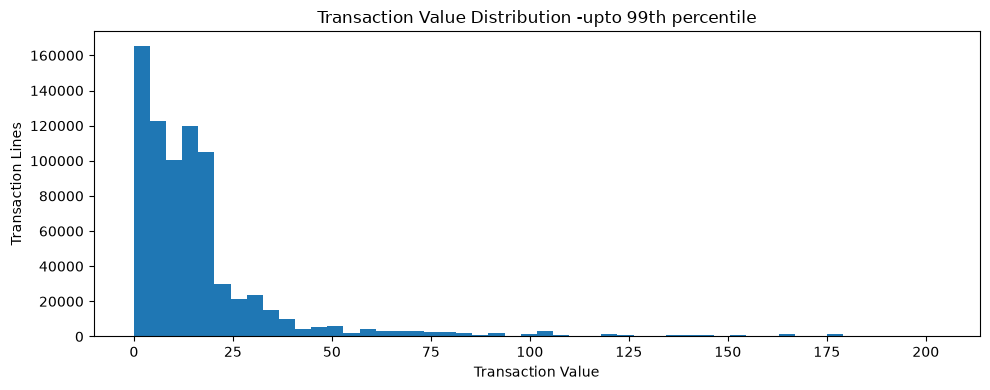

In [34]:
plt.figure(figsize=(10,4))

plt.hist(
    df.loc[df["transaction_value"]<=value_99,"transaction_value"],
    bins=50
)
plt.xlabel("Transaction Value")
plt.ylabel("Transaction Lines")
plt.title("Transaction Value Distribution -upto 99th percentile")
plt.tight_layout()
plt.show()

In [35]:
transaction_flags = ["is_cancellation","is_adjustment","is_operational_negative","is_zero_quantity","is_zero_price_activity","is_purchase"]
df[transaction_flags].sum().sort_values(ascending=False)

is_purchase                779425
is_zero_price_activity         70
is_adjustment                   0
is_cancellation                 0
is_zero_quantity                0
is_operational_negative         0
dtype: int64

In [36]:
transaction_composition = pd.DataFrame({
    "count":df[transaction_flags].sum(),
    "percentage":df[transaction_flags].mean()*100
}).sort_values("count",ascending=False)

transaction_composition

,count,percentage
is_purchase,779425,99.99102
is_zero_price_activity,70,0.00898
is_adjustment,0,0.00000
is_cancellation,0,0.00000
is_zero_quantity,0,0.00000
is_operational_negative,0,0.00000


In [38]:
zero_price = df[df["is_zero_price_activity"]]
print(f"Zero-Price customer activity : {len(zero_price)}")
print(f"Customers involved : {zero_price['customer_id'].nunique()}")

Zero-Price customer activity : 70
Customers involved : 51


In [40]:
zero_price.groupby("country").size().sort_values(ascending=False).head()

country
United Kingdom    46
Germany            8
Netherlands        5
Australia          3
EIRE               2
dtype: int64

In [49]:
monthly_stats = (
    df.set_index("invoice_date")
    .resample("ME")
    .agg(
        transactions=("invoice","size"),
        revenue=("transaction_value","sum"),
        average_value=("transaction_value","mean") 
    )
)
monthly_stats.head()

,transactions,revenue,average_value
invoice_date,,,
2009-12-31,30279,683504.010,22.573533
2010-01-31,21461,555802.672,25.898265
2010-02-28,23042,504558.956,21.897359
2010-03-31,31783,696978.471,21.929285
2010-04-30,26834,591982.002,22.060893


In [50]:
monthly_stats[["transactions","revenue","average_value"]].sort_values("revenue",ascending=False)
monthly_stats.head()

,transactions,revenue,average_value
invoice_date,,,
2009-12-31,30279,683504.010,22.573533
2010-01-31,21461,555802.672,25.898265
2010-02-28,23042,504558.956,21.897359
2010-03-31,31783,696978.471,21.929285
2010-04-30,26834,591982.002,22.060893


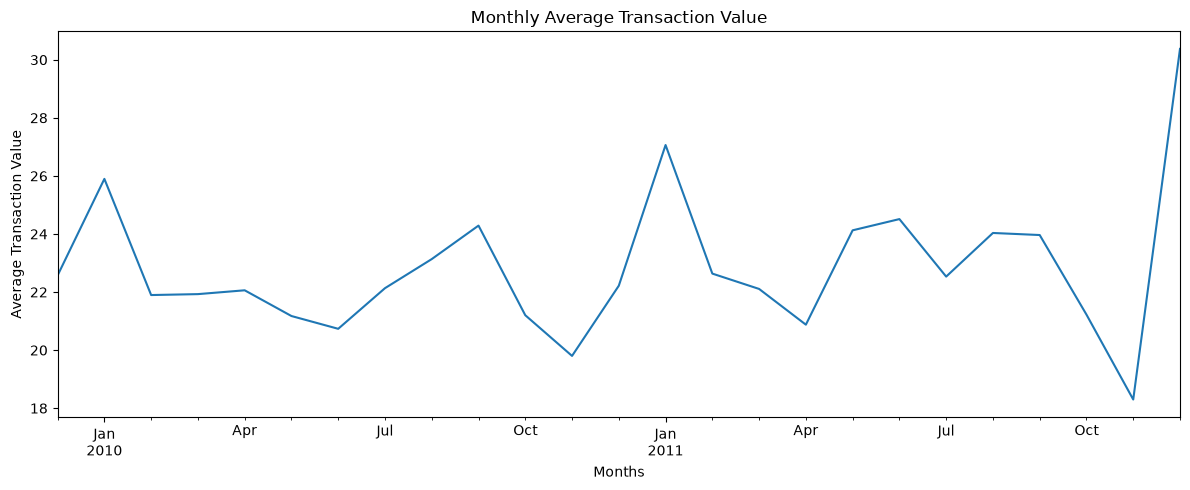

In [51]:
plt.figure(figsize=(12,5))

monthly_stats["average_value"].plot()

plt.xlabel("Months")
plt.ylabel("Average Transaction Value")
plt.title("Monthly Average Transaction Value")
plt.tight_layout()
plt.show()

### Section 1 Findings

- The processed dataset contains 779,495 transaction lines covering 5,881 customers, 36,975 orders, 4,631 products, and 41 countries.
- The dataset contains no missing values or exact duplicate rows after cleaning.
- Transaction activity exhibits strong recurring year-end seasonality, with substantial increases during October-November. December 2011 is incomplete and must be treated cautiously in temporal analysis.
- Monthly transaction value broadly follows transaction volume, while average transaction value remains comparatively stable across most complete months.
- Quantity, unit price, and transaction value are all strongly right-skewed, with extreme upper-tail observations. These observations will be investigated rather than automatically removed.
- The median transaction contains 6 units and has a value of 12.48, while the corresponding 99th percentiles are substantially larger.
- The final dataset consists almost entirely of standard purchase transactions, with only 70 retained zero-price customer activities.
- The strong skewness of monetary and quantity variables suggests that customer-level aggregation and feature engineering may require robust statistics or transformations.

## 2. Transaction & Order Behavior

The cleaned dataset is available at transaction-line level, where each row
represents a product within an invoice. This section aggregates transaction
lines into customer orders to understand order size, value, product diversity,
and purchasing structure.

In [4]:
order_df = (
    df.groupby(["customer_id","invoice"],as_index=False)
    .agg(
        order_date=("invoice_date","min"),
        order_value=("transaction_value","sum"),
        total_quantity=("quantity","sum"),
        unique_products=("stock_code","nunique"),
        transaction_lines=("stock_code","size"),
        country=("country","first")
    )
)
order_df.head()

,customer_id,invoice,order_date,order_value,total_quantity,unique_products,transaction_lines,country
0,12346.0,491725,2009-12-14 08:34:00,45.0,10,1,1,United Kingdom
1,12346.0,491742,2009-12-14 11:00:00,22.5,5,1,1,United Kingdom
2,12346.0,491744,2009-12-14 11:02:00,22.5,5,1,1,United Kingdom
3,12346.0,492718,2009-12-18 10:47:00,22.5,5,1,1,United Kingdom
4,12346.0,492722,2009-12-18 10:55:00,1.0,1,1,1,United Kingdom


In [5]:
print(f"Order rows : {len(order_df)}")
print(f"Unique Customers : {order_df['customer_id'].nunique()}")
print(f"Unique Invoices : {order_df['invoice'].nunique()}")

Order rows : 36975
Unique Customers : 5881
Unique Invoices : 36975


In [6]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36975 entries, 0 to 36974
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        36975 non-null  float64       
 1   invoice            36975 non-null  int64         
 2   order_date         36975 non-null  datetime64[ns]
 3   order_value        36975 non-null  float64       
 4   total_quantity     36975 non-null  int64         
 5   unique_products    36975 non-null  int64         
 6   transaction_lines  36975 non-null  int64         
 7   country            36975 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 2.3+ MB


In [7]:
order_df["transaction_lines"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count    36975.000000
mean        21.081677
std         22.964145
min          1.000000
25%          6.000000
50%         15.000000
75%         27.000000
90%         47.000000
95%         62.000000
99%        105.000000
max        542.000000
Name: transaction_lines, dtype: float64

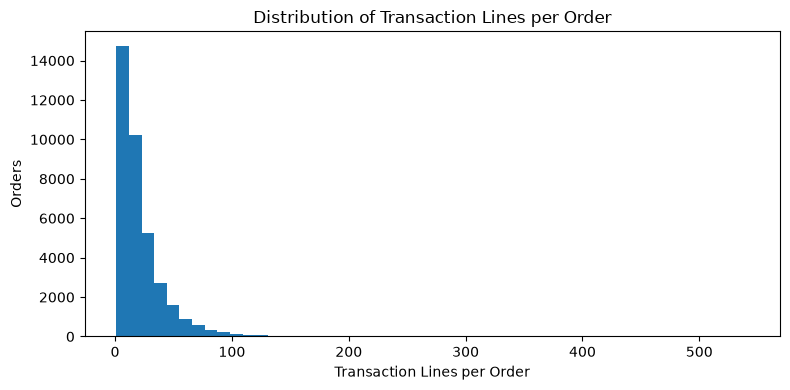

In [8]:
plt.figure(figsize=(8,4))

plt.hist(
    order_df["transaction_lines"],
    bins=50
)
plt.xlabel("Transaction Lines per Order")
plt.ylabel("Orders")
plt.title("Distribution of Transaction Lines per Order")
plt.tight_layout()
plt.show()

In [9]:
order_df["unique_products"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count    36975.000000
mean        20.795808
std         22.399384
min          1.000000
25%          6.000000
50%         15.000000
75%         27.000000
90%         46.000000
95%         61.000000
99%        101.000000
max        541.000000
Name: unique_products, dtype: float64

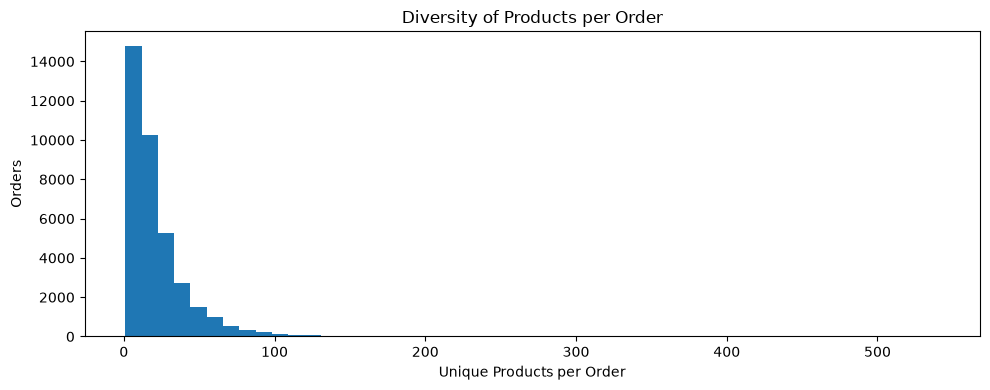

In [10]:
plt.figure(figsize=(10,4))

plt.hist(
    order_df["unique_products"],
    bins=50
)
plt.xlabel("Unique Products per Order")
plt.ylabel("Orders")
plt.title("Diversity of Products per Order")
plt.tight_layout()
plt.show()

In [11]:
order_df["total_quantity"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count    36975.000000
mean       284.751995
std       1234.056056
min          1.000000
25%         72.000000
50%        151.000000
75%        287.000000
90%        513.000000
95%        776.000000
99%       2264.080000
max      87167.000000
Name: total_quantity, dtype: float64

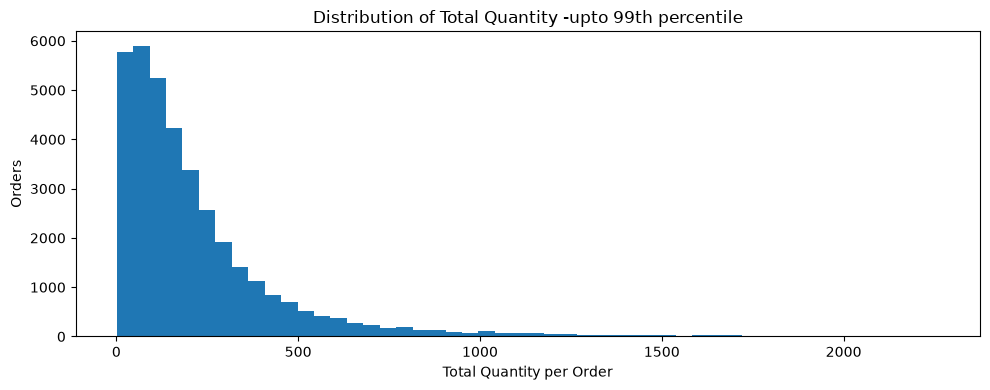

In [12]:
quantity_order_99 = order_df["total_quantity"].quantile(0.99)

plt.figure(figsize=(10,4))

plt.hist(
    order_df.loc[order_df["total_quantity"] <= quantity_order_99,"total_quantity"],
    bins=50
)
plt.xlabel("Total Quantity per Order")
plt.ylabel("Orders")
plt.title("Distribution of Total Quantity -upto 99th percentile")
plt.tight_layout()
plt.show()

In [13]:
print(f"99th percentile : {quantity_order_99}")
print(f"Maximum : {order_df['total_quantity'].max()}")

99th percentile : 2264.0800000000163
Maximum : 87167


In [14]:
order_df["order_value"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count     36975.000000
mean        469.906809
std        1359.644775
min           0.000000
25%         157.880000
50%         303.030000
75%         477.200000
90%         832.548000
95%        1230.870000
99%        3610.500000
max      168469.600000
Name: order_value, dtype: float64

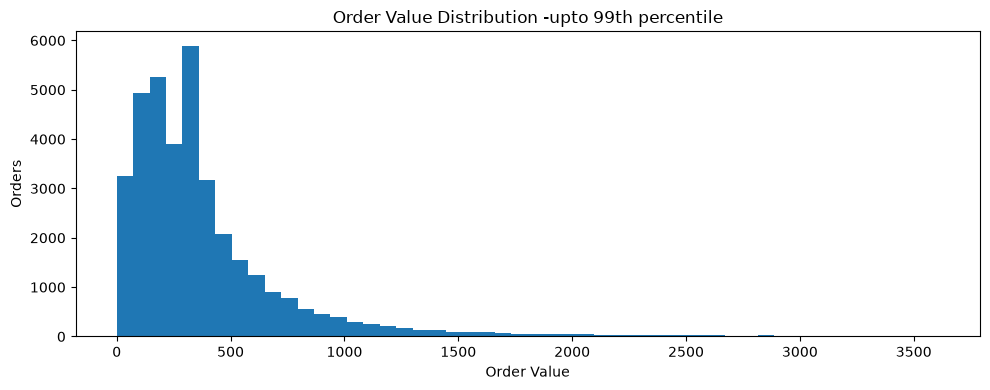

In [5]:
order_value_99 = order_df["order_value"].quantile(0.99)

plt.figure(figsize=(10,4))
plt.hist(
    order_df.loc[ order_df["order_value"] <= order_value_99 , "order_value"],
    bins=50
)
plt.xlabel("Order Value")
plt.ylabel("Orders")
plt.title("Order Value Distribution -upto 99th percentile")
plt.tight_layout()
plt.show()

In [16]:
print(f"99th percentile :{order_value_99}")
print(f"Maximum : {order_df['order_value'].max()}")

99th percentile :3610.5
Maximum : 168469.6


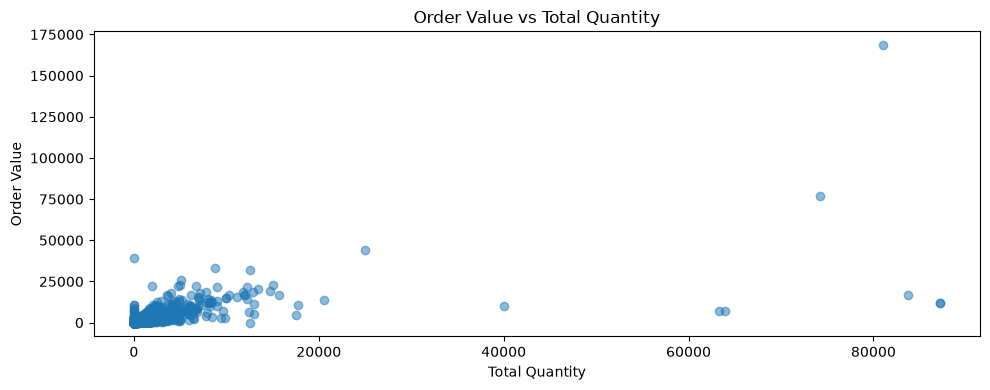

In [17]:
plt.figure(figsize=(10,4))
plt.scatter(
    order_df["total_quantity"],
    order_df["order_value"],
    alpha=0.5
)
plt.xlabel("Total Quantity")
plt.ylabel("Order Value")
plt.title("Order Value vs Total Quantity")
plt.tight_layout()
plt.show()

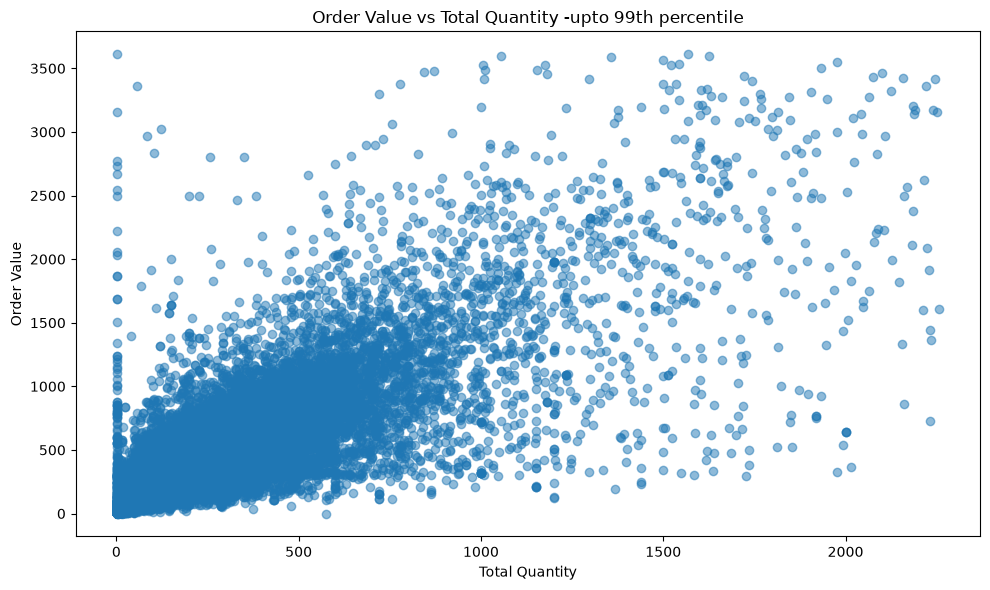

In [18]:
plot_df = order_df[ (order_df["total_quantity"] <= quantity_order_99 )&(order_df["order_value"] <= order_value_99)]

plt.figure(figsize=(10,6))
plt.scatter(
    plot_df["total_quantity"],
    plot_df["order_value"],
    alpha=0.5
)
plt.xlabel("Total Quantity")
plt.ylabel("Order Value")
plt.title("Order Value vs Total Quantity -upto 99th percentile")
plt.tight_layout()
plt.show()

In [19]:
order_df[["total_quantity","unique_products","transaction_lines","order_value"]].corr()

,total_quantity,unique_products,transaction_lines,order_value
total_quantity,1.000000,0.111495,0.108890,0.650928
unique_products,0.111495,1.000000,0.998880,0.162598
transaction_lines,0.108890,0.998880,1.000000,0.158868
order_value,0.650928,0.162598,0.158868,1.000000


In [20]:
order_df.sort_values("order_value",ascending=False).head()

,customer_id,invoice,order_date,order_value,total_quantity,unique_products,transaction_lines,country
25638,16446.0,581483,2011-12-09 09:15:00,168469.6,80995,1,1,United Kingdom
11,12346.0,541431,2011-01-18 10:01:00,77183.6,74215,1,1,United Kingdom
11309,14156.0,493819,2010-01-07 12:34:00,44051.6,25018,94,94,EIRE
17838,15098.0,556444,2011-06-10 15:28:00,38970.0,60,1,1,United Kingdom
31575,17450.0,524181,2010-09-27 16:59:00,33167.8,8820,14,14,United Kingdom


In [6]:
sorted_orders= (order_df.sort_values("order_value",ascending=False).reset_index(drop=True))
sorted_orders["cummulative_revenue"]=sorted_orders["order_value"].cumsum()
sorted_orders["cummulative_revenue_pct"]= sorted_orders["cummulative_revenue"]/sorted_orders["order_value"].sum()*100
sorted_orders["cummulative_orders_pct"]=(sorted_orders.index+1)/len(sorted_orders)*100
sorted_orders.head()

,customer_id,invoice,order_date,order_value,total_quantity,unique_products,transaction_lines,country,cummulative_revenue,cummulative_revenue_pct,cummulative_orders_pct
0,16446.0,581483,2011-12-09 09:15:00,168469.6,80995,1,1,United Kingdom,168469.6,0.969620,0.002705
1,12346.0,541431,2011-01-18 10:01:00,77183.6,74215,1,1,United Kingdom,245653.2,1.413847,0.005409
2,14156.0,493819,2010-01-07 12:34:00,44051.6,25018,94,94,EIRE,289704.8,1.667385,0.008114
3,15098.0,556444,2011-06-10 15:28:00,38970.0,60,1,1,United Kingdom,328674.8,1.891675,0.010818
4,17450.0,524181,2010-09-27 16:59:00,33167.8,8820,14,14,United Kingdom,361842.6,2.082571,0.013523


In [7]:
for order_pct in [1, 5, 10, 20, 50]:

    revenue_pct = np.interp(
        order_pct,
        sorted_orders["cummulative_orders_pct"],
        sorted_orders["cummulative_revenue_pct"]
    )

    print(
        f"Top {order_pct}% of orders generate "
        f"{revenue_pct:.2f}% of revenue"
    )

Top 1% of orders generate 17.12% of revenue
Top 5% of orders generate 33.19% of revenue
Top 10% of orders generate 43.79% of revenue
Top 20% of orders generate 58.08% of revenue
Top 50% of orders generate 83.15% of revenue


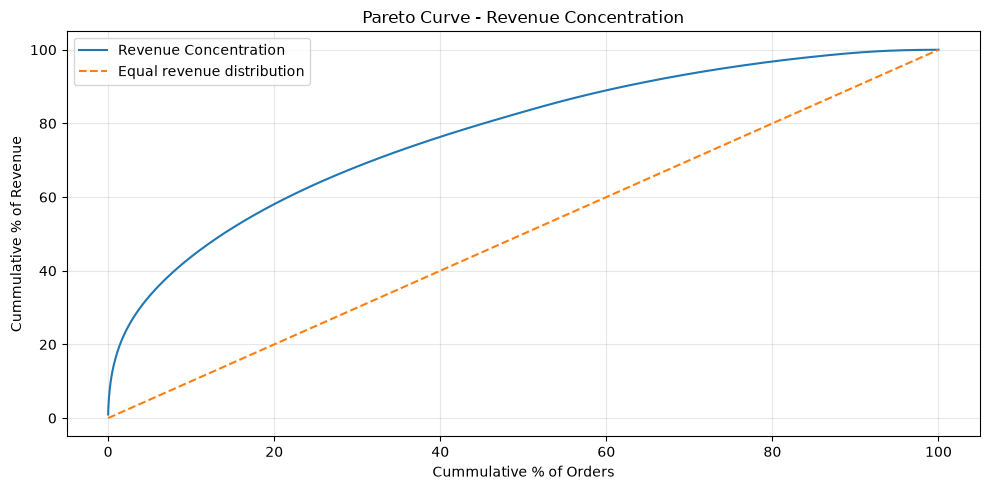

In [8]:
plt.figure(figsize=(10,5))

plt.plot(
    sorted_orders["cummulative_orders_pct"],
    sorted_orders["cummulative_revenue_pct"],
    label="Revenue Concentration"
)

plt.plot(
    [0,100],
    [0,100],
    linestyle="--",
    label="Equal revenue distribution"
)
plt.xlabel("Cummulative % of Orders")
plt.ylabel("Cummulative % of Revenue")
plt.title("Pareto Curve - Revenue Concentration")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
customer_df = (
    order_df
    .groupby("customer_id", as_index=False)
    .agg(
        total_revenue=("order_value", "sum"),
        total_orders=("invoice", "nunique"),
        total_quantity=("total_quantity", "sum"),
        unique_products=("unique_products", "sum")
    )
)

customer_df.head()

,customer_id,total_revenue,total_orders,total_quantity,unique_products
0,12346.0,77556.46,12,74285,34
1,12347.0,4921.53,8,2967,222
2,12348.0,2019.40,5,2714,47
3,12349.0,4428.69,4,1624,175
4,12350.0,334.40,1,197,17


In [10]:
customer_product_diversity = (
    df.groupby("customer_id")["stock_code"]
      .nunique()
      .rename("unique_products")
)

customer_df = customer_df.drop(
    columns="unique_products"
).merge(
    customer_product_diversity,
    on="customer_id"
)

In [11]:
customer_pareto = (
    customer_df
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

customer_pareto["cumulative_revenue"] = (
    customer_pareto["total_revenue"].cumsum()
)

customer_pareto["cumulative_revenue_pct"] = (
    customer_pareto["cumulative_revenue"]
    / customer_pareto["total_revenue"].sum()
    * 100
)

customer_pareto["cumulative_customers_pct"] = (
    (customer_pareto.index + 1)
    / len(customer_pareto)
    * 100
)

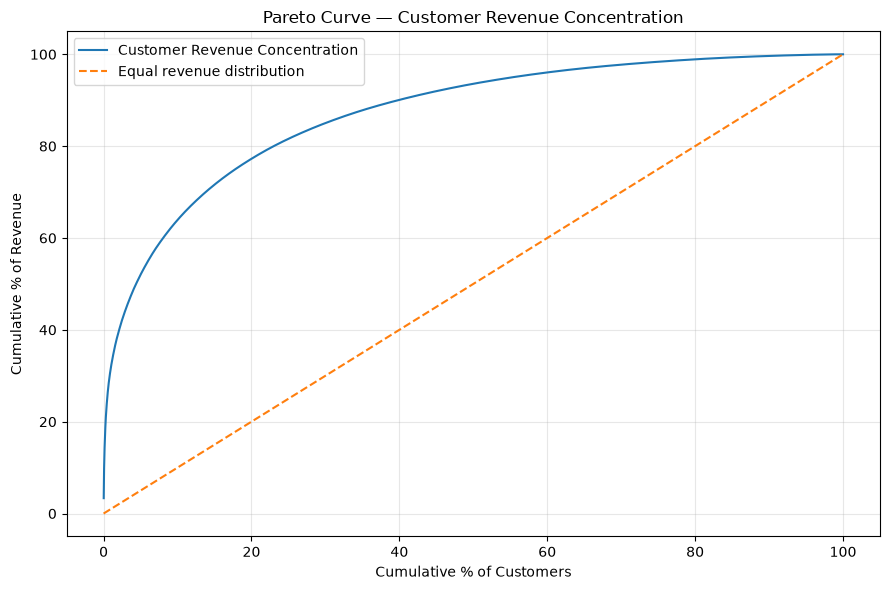

In [12]:
plt.figure(figsize=(9, 6))

plt.plot(
    customer_pareto["cumulative_customers_pct"],
    customer_pareto["cumulative_revenue_pct"],
    label="Customer Revenue Concentration"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Equal revenue distribution"
)

plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")
plt.title("Pareto Curve — Customer Revenue Concentration")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
for customer_pct in [1, 5, 10, 20, 50]:

    revenue_pct = np.interp(
        customer_pct,
        customer_pareto["cumulative_customers_pct"],
        customer_pareto["cumulative_revenue_pct"]
    )

    print(
        f"Top {customer_pct}% of customers generate "
        f"{revenue_pct:.2f}% of revenue"
    )

Top 1% of customers generate 31.93% of revenue
Top 5% of customers generate 52.01% of revenue
Top 10% of customers generate 63.93% of revenue
Top 20% of customers generate 77.25% of revenue
Top 50% of customers generate 93.58% of revenue


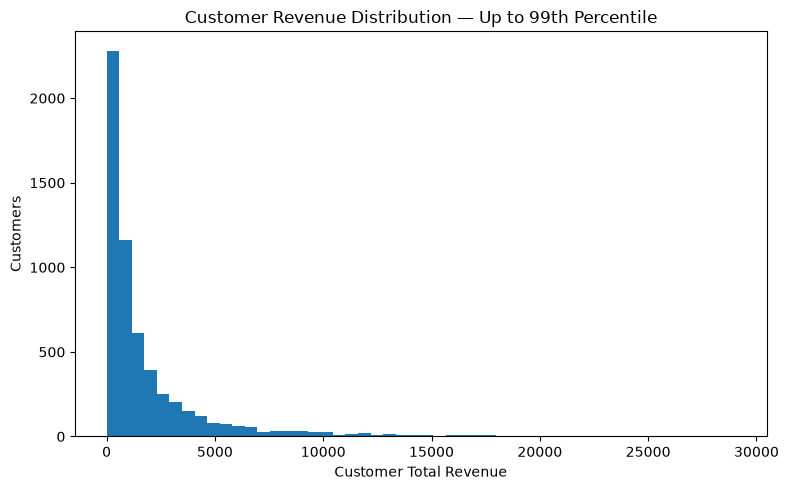

In [14]:
customer_revenue_99 = customer_df["total_revenue"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    customer_df.loc[
        customer_df["total_revenue"] <= customer_revenue_99,
        "total_revenue"
    ],
    bins=50
)

plt.xlabel("Customer Total Revenue")
plt.ylabel("Customers")
plt.title(
    "Customer Revenue Distribution — Up to 99th Percentile"
)

plt.tight_layout()
plt.show()

In [15]:
customer_df = (
    order_df
    .groupby("customer_id", as_index=False)
    .agg(
        total_orders=("invoice", "nunique"),
        total_spend=("order_value", "sum"),
        total_quantity=("total_quantity", "sum"),
        first_purchase=("order_date", "min"),
        last_purchase=("order_date", "max"),
        active_days=("order_date", lambda x: x.dt.date.nunique())
    )
)

customer_product_count = (
    df.groupby("customer_id")["stock_code"]
      .nunique()
      .rename("unique_products")
)

customer_df = customer_df.merge(
    customer_product_count,
    on="customer_id"
)

customer_df["average_order_value"] = (
    customer_df["total_spend"]
    / customer_df["total_orders"]
)

customer_df["customer_lifespan_days"] = (
    customer_df["last_purchase"]
    - customer_df["first_purchase"]
).dt.days

customer_df.head()

,customer_id,total_orders,total_spend,total_quantity,first_purchase,last_purchase,active_days,unique_products,average_order_value,customer_lifespan_days
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,8,27,6463.038333,400
1,12347.0,8,4921.53,2967,2010-10-31 14:20:00,2011-12-07 15:52:00,8,126,615.191250,402
2,12348.0,5,2019.40,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,5,25,403.880000,362
3,12349.0,4,4428.69,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,4,138,1107.172500,570
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,1,17,334.400000,0


In [16]:
print(customer_df.shape)
customer_df.info()

(5881, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             5881 non-null   float64       
 1   total_orders            5881 non-null   int64         
 2   total_spend             5881 non-null   float64       
 3   total_quantity          5881 non-null   int64         
 4   first_purchase          5881 non-null   datetime64[ns]
 5   last_purchase           5881 non-null   datetime64[ns]
 6   active_days             5881 non-null   int64         
 7   unique_products         5881 non-null   int64         
 8   average_order_value     5881 non-null   float64       
 9   customer_lifespan_days  5881 non-null   int64         
dtypes: datetime64[ns](2), float64(3), int64(5)
memory usage: 459.6 KB


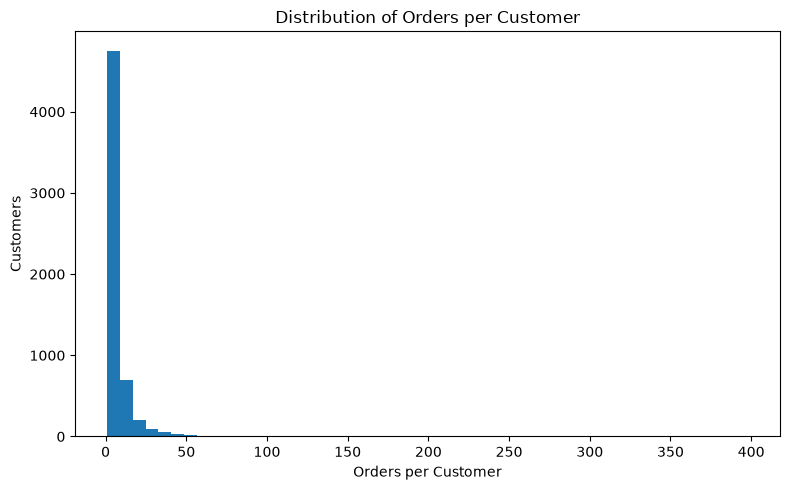

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(customer_df["total_orders"], bins=50)

plt.xlabel("Orders per Customer")
plt.ylabel("Customers")
plt.title("Distribution of Orders per Customer")

plt.tight_layout()
plt.show()

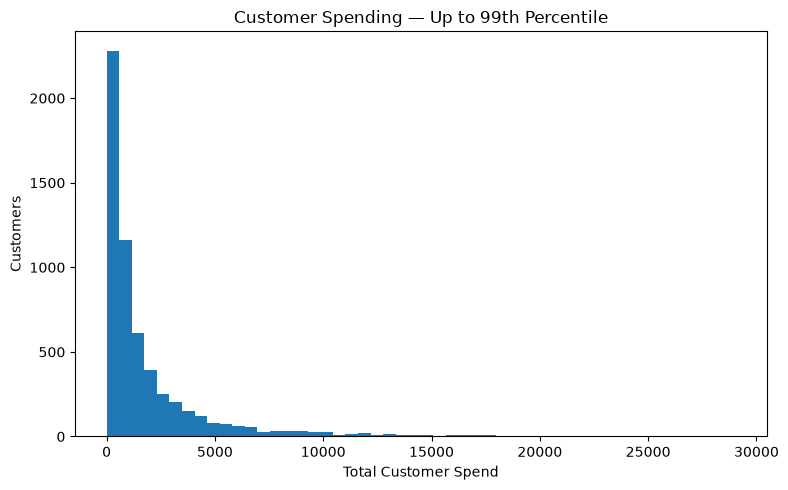

In [18]:
spend_99 = customer_df["total_spend"].quantile(.99)

plt.figure(figsize=(8, 5))

plt.hist(
    customer_df.loc[
        customer_df["total_spend"] <= spend_99,
        "total_spend"
    ],
    bins=50
)

plt.xlabel("Total Customer Spend")
plt.ylabel("Customers")
plt.title("Customer Spending — Up to 99th Percentile")

plt.tight_layout()
plt.show()

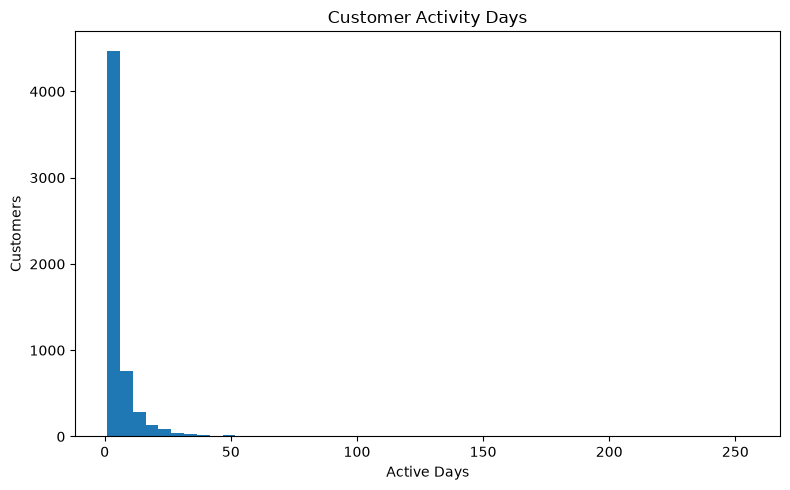

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    customer_df["active_days"],
    bins=50
)

plt.xlabel("Active Days")
plt.ylabel("Customers")
plt.title("Customer Activity Days")

plt.tight_layout()
plt.show()

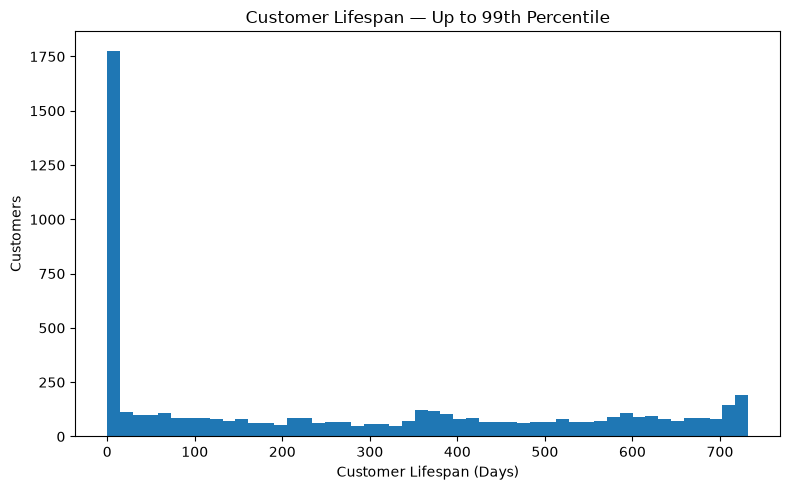

In [20]:
lifespan_99 = customer_df["customer_lifespan_days"].quantile(.99)

plt.figure(figsize=(8, 5))

plt.hist(
    customer_df.loc[
        customer_df["customer_lifespan_days"] <= lifespan_99,
        "customer_lifespan_days"
    ],
    bins=50
)

plt.xlabel("Customer Lifespan (Days)")
plt.ylabel("Customers")
plt.title("Customer Lifespan — Up to 99th Percentile")

plt.tight_layout()
plt.show()

In [21]:
customer_df[
    [
        "total_orders",
        "total_spend",
        "average_order_value",
        "total_quantity",
        "unique_products",
        "active_days",
        "customer_lifespan_days"
    ]
].describe(
    percentiles=[
        .25, .50, .75, .90, .95, .99
    ]
)

,total_orders,total_spend,average_order_value,total_quantity,unique_products,active_days,customer_lifespan_days
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,6.287196,2954.396237,384.975880,1790.291617,81.949838,5.630335,272.883183
std,13.012879,14437.322635,1213.998407,8882.005013,116.475103,10.001176,258.815005
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,341.900000,176.627143,186.000000,19.000000,1.000000,0.000000
50%,3.000000,865.600000,279.129091,480.000000,45.000000,3.000000,220.000000
75%,7.000000,2247.720000,414.895714,1350.000000,103.000000,6.000000,511.000000
90%,13.000000,5464.850000,631.350000,3179.000000,198.000000,12.000000,667.000000
95%,21.000000,9371.710000,890.934118,5356.000000,281.000000,19.000000,712.000000
99%,46.000000,29181.400000,1962.660000,17080.000000,502.600000,39.000000,732.000000


In [22]:
customer_type = pd.Series(
    np.where(
        customer_df["total_orders"] == 1,
        "one-time",
        "repeat"
    ),
    name="customer_type"
)

customer_type.value_counts()

customer_type
repeat      4255
one-time    1626
Name: count, dtype: int64

In [23]:
customer_type.value_counts(normalize=True) * 100

customer_type
repeat      72.351641
one-time    27.648359
Name: proportion, dtype: float64

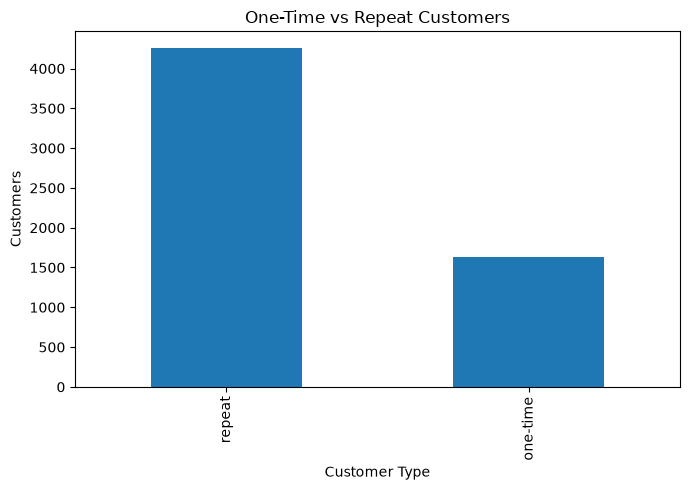

In [24]:
customer_type.value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Customer Type")
plt.ylabel("Customers")
plt.title("One-Time vs Repeat Customers")

plt.tight_layout()
plt.show()

In [25]:
customer_df["customer_type"] = np.where(
    customer_df["total_orders"] == 1,
    "one-time",
    "repeat"
)

customer_df.groupby("customer_type").agg(
    customers=("customer_id", "count"),
    revenue=("total_spend", "sum"),
    average_spend=("total_spend", "mean")
)

,customers,revenue,average_spend
customer_type,,,
one-time,1626,5.602726e+05,344.571071
repeat,4255,1.681453e+07,3951.711329


In [27]:
order_history = order_df.sort_values(
    ["customer_id", "order_date"]
).copy()

order_history["days_since_previous_order"] = (
    order_history
    .groupby("customer_id")["order_date"]
    .diff()
    .dt.total_seconds()
    / (60 * 60 * 24)
)
order_history["days_since_previous_order"].describe(
    percentiles=[
        .25, .50, .75, .90, .95, .99
    ]
)

count    31094.000000
mean        51.681669
std         75.786619
min          0.000000
25%          6.983333
50%         24.740972
75%         61.804340
90%        134.864653
95%        206.324549
99%        368.730826
max        714.152083
Name: days_since_previous_order, dtype: float64

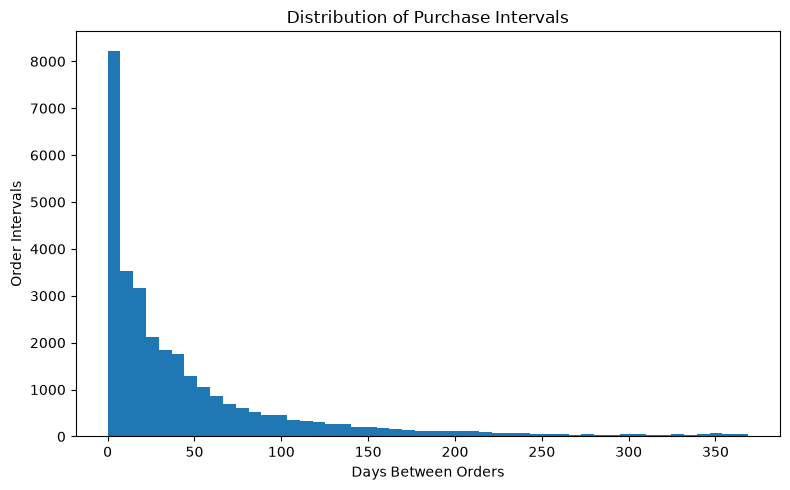

In [28]:
intervals = order_history[
    "days_since_previous_order"
].dropna()

interval_99 = intervals.quantile(.99)

plt.figure(figsize=(8, 5))

plt.hist(
    intervals[intervals <= interval_99],
    bins=50
)

plt.xlabel("Days Between Orders")
plt.ylabel("Order Intervals")
plt.title("Distribution of Purchase Intervals")

plt.tight_layout()
plt.show()

In [29]:
analysis_date = df["invoice_date"].max()

customer_df["recency_days"] = (
    analysis_date
    - customer_df["last_purchase"]
).dt.days
customer_df["recency_days"].describe(
    percentiles=[
        .25, .50, .75, .90, .95, .99
    ]
)

count    5881.000000
mean      200.457745
std       209.474135
min         0.000000
25%        25.000000
50%        95.000000
75%       379.000000
90%       535.000000
95%       625.000000
99%       725.000000
max       738.000000
Name: recency_days, dtype: float64

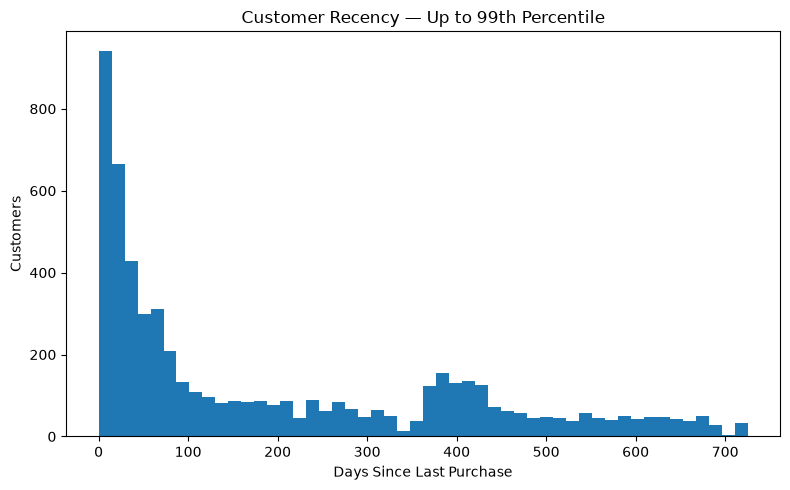

In [30]:
recency_99 = customer_df["recency_days"].quantile(.99)

plt.figure(figsize=(8, 5))

plt.hist(
    customer_df.loc[
        customer_df["recency_days"] <= recency_99,
        "recency_days"
    ],
    bins=50
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customers")
plt.title("Customer Recency — Up to 99th Percentile")

plt.tight_layout()
plt.show()

In [31]:
customer_df[
    [
        "total_orders",
        "total_spend",
        "average_order_value",
        "total_quantity",
        "unique_products",
        "active_days",
        "customer_lifespan_days",
        "recency_days"
    ]
].corr()

,total_orders,total_spend,average_order_value,total_quantity,unique_products,active_days,customer_lifespan_days,recency_days
total_orders,1.000000,0.628148,0.033807,0.571864,0.693186,0.968504,0.441860,-0.256923
total_spend,0.628148,1.000000,0.268815,0.874538,0.407994,0.553458,0.212742,-0.124965
average_order_value,0.033807,0.268815,1.000000,0.257487,0.050219,0.027156,0.015481,-0.027521
total_quantity,0.571864,0.874538,0.257487,1.000000,0.388786,0.509726,0.200747,-0.110212
unique_products,0.693186,0.407994,0.050219,0.388786,1.000000,0.706480,0.499286,-0.325557
active_days,0.968504,0.553458,0.027156,0.509726,0.706480,1.000000,0.497679,-0.295391
customer_lifespan_days,0.441860,0.212742,0.015481,0.200747,0.499286,0.497679,1.000000,-0.563535
recency_days,-0.256923,-0.124965,-0.027521,-0.110212,-0.325557,-0.295391,-0.563535,1.000000


### Section 3 Findings — Customer Behavior

- Customer behavior is strongly right-skewed, with most customers placing relatively few orders and a smaller group exhibiting substantially higher purchase frequency.
- Customer spending is also highly right-skewed, confirming that customer value is concentrated among a relatively small portion of the customer base.
- Repeat customers form the majority of the customer base, while one-time customers represent a significant segment that should be distinguished from established customers.
- Purchase intervals exhibit a long right tail. Most repeat purchases occur relatively close together, while some customers have gaps extending for several months.
- Customer recency is similarly right-skewed, with most customers having relatively recent activity but a substantial long-tail group showing extended inactivity.
- The strong correlation between order frequency and active days (0.969) indicates substantial feature redundancy. Total orders and active days should therefore be evaluated carefully during later feature engineering.
- Total spend has a strong relationship with total quantity (0.875), while average order value has little relationship with order frequency, suggesting that customer frequency and monetary value capture different aspects of customer behavior.
- Overall, customer behavior varies substantially across frequency, monetary value, product diversity, and recency. These dimensions provide important foundations for subsequent churn feature engineering.

In [33]:
monthly = (
    order_df
    .groupby("month")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("invoice", "nunique"),
        revenue=("order_value", "sum")
    )
)

monthly.head()

,customers,orders,revenue
month,,,
2009-12,955,1512,683504.010
2010-01,720,1011,555802.672
2010-02,774,1106,504558.956
2010-03,1057,1524,696978.471
2010-04,942,1329,591982.002


In [40]:
top_products_revenue = (
    df.groupby(["stock_code", "description"])
      .agg(
          revenue=("transaction_value", "sum"),
          quantity=("quantity", "sum"),
          customers=("customer_id", "nunique")
      )
      .sort_values("revenue", ascending=False)
      .head(20)
)

top_products_revenue.head()

,,revenue,quantity,customers
stock_code,description,,,
22423,REGENCY CAKESTAND 3 TIER,277656.25,24139,1314
85123A,WHITE HANGING HEART T-LIGHT HOLDER,247048.01,91757,1490
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
M,Manual,151777.67,9391,443
85099B,JUMBO BAG RED RETROSPOT,134307.44,74224,860


In [46]:
top_products_frequency = (
    df.groupby("stock_code")
      .agg(
          transaction_lines=("invoice", "count"),
          quantity=("quantity", "sum"),
          customers=("customer_id", "nunique")
      )
      .sort_values("transaction_lines", ascending=False)
      .head(20)
)

top_products_frequency.head()

,transaction_lines,quantity,customers
stock_code,,,
85123A,5023,91814,1490
22423,3337,24139,1314
85099B,3296,93436,978
84879,2692,78234,1010
20725,2609,37750,845


In [48]:
product_revenue = (
    df.groupby("stock_code")["transaction_value"]
      .sum()
      .sort_values(ascending=False)
)

cumulative_revenue = (
    product_revenue.cumsum()
    / product_revenue.sum()
    * 100
)

cumulative_products = (
    np.arange(1, len(product_revenue) + 1)
    / len(product_revenue)
    * 100
)

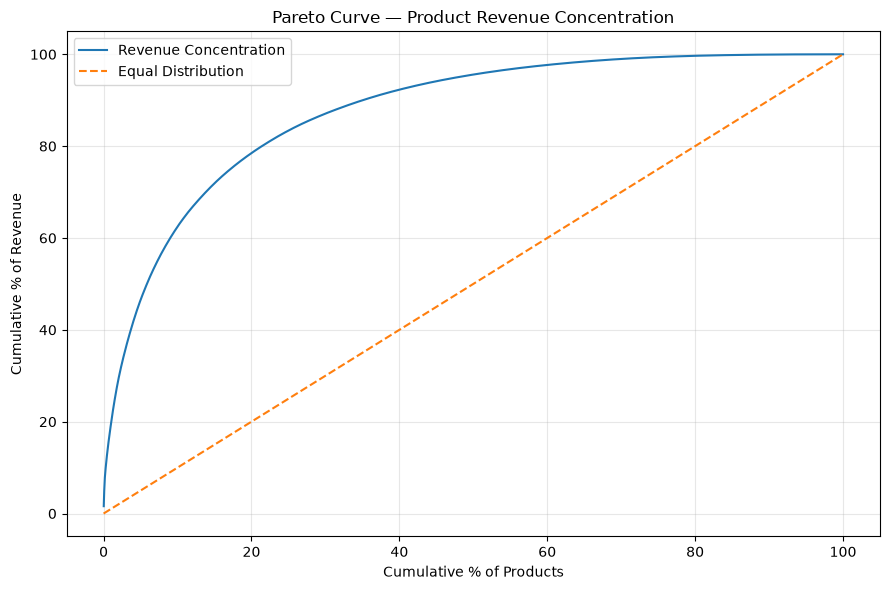

In [49]:
plt.figure(figsize=(9, 6))

plt.plot(
    cumulative_products,
    cumulative_revenue,
    label="Revenue Concentration"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Equal Distribution"
)

plt.xlabel("Cumulative % of Products")
plt.ylabel("Cumulative % of Revenue")
plt.title("Pareto Curve — Product Revenue Concentration")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
for percentage in [1, 5, 10, 20, 50]:
    index = int(len(product_revenue) * percentage / 100) - 1
    revenue_share = cumulative_revenue.iloc[index]

    print(
        f"Top {percentage}% of products generate "
        f"{revenue_share:.2f}% of revenue"
    )

Top 1% of products generate 19.46% of revenue
Top 5% of products generate 46.45% of revenue
Top 10% of products generate 62.46% of revenue
Top 20% of products generate 78.48% of revenue
Top 50% of products generate 95.59% of revenue


In [51]:
customer_df["unique_products"].describe(
    percentiles=[.25, .50, .75, .90, .95, .99]
)

count    5881.000000
mean       81.949838
std       116.475103
min         1.000000
25%        19.000000
50%        45.000000
75%       103.000000
90%       198.000000
95%       281.000000
99%       502.600000
max      2550.000000
Name: unique_products, dtype: float64

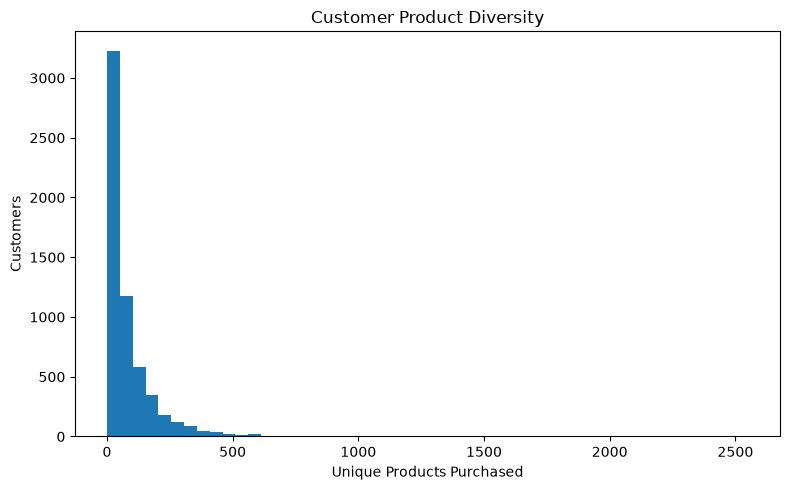

In [52]:
plt.figure(figsize=(8, 5))

plt.hist(
    customer_df["unique_products"],
    bins=50
)

plt.xlabel("Unique Products Purchased")
plt.ylabel("Customers")
plt.title("Customer Product Diversity")

plt.tight_layout()
plt.show()

In [54]:
country_summary = (
    order_df.groupby("country")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("invoice", "nunique"),
        revenue=("order_value", "sum")
    )
    .sort_values("revenue", ascending=False)
)

country_summary.head()

,customers,orders,revenue
country,,,
United Kingdom,5353,33546,1.438923e+07
EIRE,5,567,6.165705e+05
Netherlands,22,229,5.540381e+05
Germany,107,789,4.250197e+05
France,95,614,3.487690e+05


In [56]:
total_revenue = country_summary["revenue"].sum()

for n in [1, 3, 5, 10]:
    share = (
        country_summary["revenue"].head(n).sum()
        / total_revenue
        * 100
    )

    print(f"Top {n} countries → {share:.2f}% of revenue")

Top 1 countries → 82.82% of revenue
Top 3 countries → 89.55% of revenue
Top 5 countries → 94.01% of revenue
Top 10 countries → 97.10% of revenue


In [57]:
analysis_date = order_df["order_date"].max()

rfm = (
    order_df.groupby("customer_id")
    .agg(
        recency=("order_date", lambda x:
                 (analysis_date - x.max()).days),
        frequency=("invoice", "nunique"),
        monetary=("order_value", "sum")
    )
)

rfm.describe(
    percentiles=[.25, .50, .75, .90, .95, .99]
)

,recency,frequency,monetary
count,5881.000000,5881.000000,5881.000000
mean,200.457745,6.287196,2954.396237
std,209.474135,13.012879,14437.322635
min,0.000000,1.000000,0.000000
25%,25.000000,1.000000,341.900000
50%,95.000000,3.000000,865.600000
75%,379.000000,7.000000,2247.720000
90%,535.000000,13.000000,5464.850000
95%,625.000000,21.000000,9371.710000
99%,725.000000,46.000000,29181.400000


In [61]:
recency_analysis = (
    rfm.groupby("recency_group", observed=True)
    .agg(
        customers=("monetary", "count"),
        avg_frequency=("frequency", "mean"),
        avg_spend=("monetary", "mean"),
        total_revenue=("monetary", "sum")
    )
)

recency_analysis

,customers,avg_frequency,avg_spend,total_revenue
recency_group,,,,
Recent,1511,13.041694,7035.046926,1.062996e+07
Moderate,1443,5.881497,2399.879567,3.463026e+06
Old,1466,3.989086,1528.337138,2.240542e+06
Very Old,1461,2.008214,712.717251,1.041280e+06


# EDA — Final Conclusions

## 1. Transaction Behavior

- The cleaned dataset contains 779,495 transaction lines.
- Transaction and order values are strongly right-skewed.
- Most transactions are relatively small, while a small number have substantially larger quantities and values.
- Transaction activity exhibits clear temporal/seasonal variation.

## 2. Revenue Concentration

- Revenue is highly concentrated at the customer level.
- The top 10% of customers generate 63.93% of revenue.
- The top 20% generate 77.25%.
- The top 50% generate 93.58%.

This indicates that customer value is highly heterogeneous.

## 3. Customer Behavior

- Customer purchase frequency is strongly right-skewed.
- Customer spending is strongly right-skewed.
- Repeat customers form the majority of the customer base.
- Purchase intervals have a long right tail.
- Customer recency varies substantially.

## 4. Product Behavior

- Product popularity and product revenue are not necessarily identical.
- Revenue concentration across products indicates whether a small number of products drive a disproportionate amount of revenue.
- Customer product diversity varies substantially.

## 5. Geographic Behavior

- Revenue and customer activity vary significantly across countries.
- A relatively small number of countries account for a substantial share of revenue.

## 6. Churn-Relevant Behavioral Signals

The EDA identifies several variables that are potentially useful for churn prediction:

- Recency
- Purchase frequency
- Monetary value
- Average order value
- Customer lifespan
- Purchase intervals
- Product diversity
- Total quantity
- Historical activity

## 7. Feature Considerations

Some behavioral variables are strongly correlated.

For example:

- Total orders and active days show very high correlation.
- Total quantity and total spend are strongly correlated.

These relationships should be considered during feature engineering and model development to avoid unnecessary redundancy.

## 8. Business Implication

Customer revenue is highly concentrated, meaning that churn risk should eventually be evaluated together with customer value.

A high-probability churn event involving a low-value customer does not have the same business impact as churn involving a historically high-value customer.

Therefore, the final system should provide both:

1. Customer churn probability
2. Business value/risk associated with the customer